<a href="https://colab.research.google.com/github/elifnurerdemir/DI725_Term_Project/blob/main/Phase3_Notebook_ElifnurErdemir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DI 725 – Transformers and Attention-Based Deep Networks
## Term Project – Phase 3: Final Results, Ablation, and Analysis


Environment Setup

In [1]:
# Install required packages
!pip install torch torchvision transformers pandas Pillow scikit-learn wandb --quiet

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from transformers import AutoTokenizer, AutoModel, ViTModel, ViTConfig
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, hamming_loss, classification_report
import matplotlib.pyplot as plt
import wandb

SEED = 42

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
print(f"Seed set to {SEED}")

Seed set to 42


In [4]:
from IPython.display import clear_output

class EpochVisualizer:
    """
    Live-updating training dashboard

    Tracked metrics per epoch:
      train: cls_loss, grnd_loss
      val:   micro_f1, macro_f1, hamming, alpha_mean, alpha_std, f1_<class>
    """

    def __init__(self, classes: list, experiment_name: str):
        self.classes         = classes
        self.experiment_name = experiment_name

        # History buffers
        self.epochs      = []
        self.train_cls   = []
        self.train_grnd  = []
        self.val_micro   = []
        self.val_macro   = []
        self.val_hamming = []
        self.alpha_mean  = []
        self.alpha_std   = []
        self.per_class   = {cls: [] for cls in classes}  # val F1 per class

    def update(
        self,
        epoch: int,
        train_m: dict,
        val_m: dict,
    ) -> None:
        self.epochs.append(epoch)
        self.train_cls.append(train_m['cls_loss'])
        self.train_grnd.append(train_m['grnd_loss'])
        self.val_micro.append(val_m['micro_f1'])
        self.val_macro.append(val_m['macro_f1'])
        self.val_hamming.append(val_m['hamming'])
        self.alpha_mean.append(val_m['alpha_mean'])
        self.alpha_std.append(val_m['alpha_std'])
        for cls in self.classes:
            self.per_class[cls].append(val_m[f'f1_{cls}'])

        self._draw()

    def _draw(self) -> None:
        clear_output(wait=True)

        fig, axes = plt.subplots(2, 3, figsize=(15, 8))
        fig.suptitle(
            f'{self.experiment_name} – Training Dashboard  '
            f'(Epoch {self.epochs[-1]})',
            fontsize=13, fontweight='bold',
        )

        ep = self.epochs

        ax = axes[0, 0]
        ax.plot(ep, self.train_cls,  marker='o', linestyle='-',  label='Classification Loss')
        ax.plot(ep, self.train_grnd, marker='s', linestyle='--', label='Grounding Loss')
        ax.set_title('Training Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        ax = axes[0, 1]
        ax.plot(ep, self.val_micro, marker='^', linestyle='-', color='tab:green')
        ax.set_title('Validation Micro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Micro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_micro[-1]:.4f}',
            xy=(ep[-1], self.val_micro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Validation Macro-F1 Table
        ax = axes[0, 2]
        ax.plot(ep, self.val_macro, marker='D', linestyle='-', color='tab:orange')
        ax.set_title('Validation Macro-F1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Macro-F1')
        ax.set_ylim(0, 1)
        ax.annotate(
            f'{self.val_macro[-1]:.4f}',
            xy=(ep[-1], self.val_macro[-1]),
            xytext=(5, -12), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Hamming Loss Table
        ax = axes[1, 0]
        ax.plot(ep, self.val_hamming, marker='x', linestyle='-', color='tab:red')
        ax.set_title('Validation Hamming Loss')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Hamming Loss')
        ax.set_ylim(0, max(self.val_hamming) * 1.2 + 1e-6)
        ax.annotate(
            f'{self.val_hamming[-1]:.4f}',
            xy=(ep[-1], self.val_hamming[-1]),
            xytext=(5, 5), textcoords='offset points', fontsize=9,
        )
        ax.grid(True, linestyle=':')

        # Dynamic Reliability Coefficient α
        ax = axes[1, 1]
        means = np.array(self.alpha_mean)
        stds  = np.array(self.alpha_std)
        ax.plot(ep, means, marker='o', linestyle='-', color='tab:purple', label='Mean α')
        ax.fill_between(ep, means - stds, means + stds, alpha=0.25, color='tab:purple', label='±1 std')
        ax.axhline(0.5, color='grey', linestyle=':', linewidth=1, label='α=0.5 (balanced)')
        ax.set_title('Dynamic Reliability Coefficient α')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('α')
        ax.set_ylim(0, 1)
        ax.legend(fontsize=8)
        ax.grid(True, linestyle=':')

        # Per-class F1 (latest epoch)
        ax = axes[1, 2]
        latest_f1 = [self.per_class[cls][-1] for cls in self.classes]
        bars = ax.bar(
            self.classes, latest_f1,
            edgecolor='black',
            color=[
                'tab:green', 'tab:pink', 'tab:olive',
                'tab:orange', 'tab:brown', 'tab:gray', 'tab:blue'
            ],
        )
        ax.set_title(f'Per-Class F1 (Epoch {ep[-1]})')
        ax.set_ylabel('F1 Score')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=20)
        for bar, val in zip(bars, latest_f1):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7,
            )
        ax.grid(axis='y', linestyle=':')

        plt.tight_layout()
        plt.show()

1. Configuration


In [5]:
#  Paths
import shutil, os

SRC = '/content/drive/MyDrive/DI725_project_dataset'
DST = '/content/dataset'

if not os.path.exists(DST):
    print("Copying...")
    shutil.copytree(SRC, DST)
    print("Done!")
else:
    print("Already available")

BASE_PATH    = '/content/dataset'
IMG_DIR      = os.path.join(BASE_PATH, 'images')
MASK_DIR     = os.path.join(BASE_PATH, 'masks')
LABELS_CSV   = os.path.join(BASE_PATH, 'binary_labels.csv')
CAPTIONS_CSV = os.path.join(BASE_PATH, 'vision_captions_only.csv')

# ── Model & Training
DEVICE         = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASSES        = ['Tree', 'Shrub', 'Grass', 'Crop', 'Built-up', 'Barren', 'Water']
NUM_CLASSES    = len(CLASSES)
IMG_SIZE       = 224            # ViT-B/16 expects 224×224
PATCH_SIZE     = 16             # ViT-B/16 patch size
ATTN_GRID      = IMG_SIZE // PATCH_SIZE   # 14 – attention map spatial resolution
MAX_TEXT_LEN   = 128
BATCH_SIZE     = 32
NUM_EPOCHS     = 10
LEARNING_RATE  = 3e-5
VAL_SPLIT      = 0.15
TEST_SPLIT     = 0.10
ATTN_LOSS_W    = 0.1            # weight for the attention grounding loss term
VIT_EMBED_DIM  = 768
TEXT_EMBED_DIM = 768
CAPTION_COL    = 'vision_qwen3-vl-8b'
TEXT_MODEL_ID  = 'distilbert-base-uncased'

# Class colours
CLASS_RGB = {
    'Tree':     (0,   100,   0),
    'Shrub':    (255, 182, 193),
    'Grass':    (154, 205,  50),
    'Crop':     (255, 215,   0),
    'Built-up': (139,  69,  19),
    'Barren':   (211, 211, 211),
    'Water':    (0,     0, 255),
}

print(f"Device: {DEVICE}")
print(f"Attention grid: {ATTN_GRID}×{ATTN_GRID}")

Copying...
Done!
Device: cuda
Attention grid: 14×14


## 2. Dataset

### 2.1 Mask Decoding

The RGB segmentation masks are decoded per-class into binary spatial maps.  
Each map is then resized to `ATTN_GRID × ATTN_GRID` to match the ViT attention resolution.

This produces a **per-class presence mask** that is later used as the supervision signal for Attention Grounding.

In [6]:
def decode_mask(mask_path: str, class_rgb: dict, classes: list, grid: int) -> torch.Tensor:
    """
    Decode an RGB segmentation mask into a float tensor of shape (num_classes, grid, grid).
    """
    mask_img = np.array(Image.open(mask_path).convert('RGB'))  # (H, W, 3)
    H, W = mask_img.shape[:2]
    maps = []
    for cls in classes:
        r, g, b = class_rgb[cls]
        # Exact pixel match for each class colour
        binary = (
            (mask_img[:, :, 0] == r) &
            (mask_img[:, :, 1] == g) &
            (mask_img[:, :, 2] == b)
        ).astype(np.float32)  # (H, W)
        maps.append(binary)
    stacked = np.stack(maps, axis=0)  # (C, H, W)
    tensor  = torch.from_numpy(stacked).unsqueeze(0)  # (1, C, H, W)
    resized = F.interpolate(tensor, size=(grid, grid), mode='nearest')
    return resized.squeeze(0)  # (C, grid, grid)

### 2.2 Dataset Class

In [7]:
class RemoteSensingDataset(Dataset):
    """
    Multi-modal remote sensing dataset.

    """

    def __init__(
        self,
        labels_df: pd.DataFrame,
        captions_df: pd.DataFrame,
        img_dir: str,
        mask_dir: str,
        class_rgb: dict,
        classes: list,
        attn_grid: int,
        transform=None,
        tokenizer=None,
        max_text_len: int = 128,
        caption_col: str = 'vision_qwen3-vl-8b',
    ):
        self.labels_df   = labels_df.reset_index(drop=True)
        self.captions    = captions_df.set_index('filename')[caption_col].to_dict()
        self.img_dir     = img_dir
        self.mask_dir    = mask_dir
        self.class_rgb   = class_rgb
        self.classes     = classes
        self.attn_grid   = attn_grid
        self.transform   = transform
        self.tokenizer   = tokenizer
        self.max_text_len = max_text_len

    def __len__(self) -> int:
        return len(self.labels_df)

    def __getitem__(self, idx: int) -> dict:
        row      = self.labels_df.iloc[idx]
        fname    = row['filename']

        # Image
        image = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Segmentation mask (decoded to per-class attention targets)
        gt_attn = decode_mask(
            os.path.join(self.mask_dir, fname),
            self.class_rgb, self.classes, self.attn_grid
        )  # (num_classes, grid, grid)

        # Caption
        caption  = str(self.captions.get(fname, ''))
        encoding = self.tokenizer(
            caption,
            padding='max_length',
            truncation=True,
            max_length=self.max_text_len,
            return_tensors='pt',
        )

        # Labels
        labels = torch.tensor(row[self.classes].values.astype(float), dtype=torch.float32)

        return {
            'image':     image,
            'input_ids': encoding['input_ids'].squeeze(0),
            'attn_mask': encoding['attention_mask'].squeeze(0),
            'labels':    labels,
            'gt_attn':   gt_attn,
            'filename':  fname,
        }

### 2.3 Data Loading

In [8]:
def build_dataloaders(
    labels_csv: str,
    captions_csv: str,
    img_dir: str,
    mask_dir: str,
    class_rgb: dict,
    classes: list,
    attn_grid: int,
    text_model_id: str,
    batch_size: int,
    val_split: float,
    test_split: float,
    max_text_len: int,
    caption_col: str,
    seed: int,
):
    labels_df   = pd.read_csv(labels_csv)
    captions_df = pd.read_csv(captions_csv)

    tokenizer = AutoTokenizer.from_pretrained(text_model_id)

    img_transform = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    # Tandom splitting
    train_val_df, test_df = train_test_split(labels_df, test_size=test_split,  random_state=seed)
    train_df,    val_df  = train_test_split(train_val_df, test_size=val_split / (1 - test_split), random_state=seed)

    dataset_kwargs = dict(
        captions_df=captions_df,
        img_dir=img_dir, mask_dir=mask_dir,
        class_rgb=class_rgb, classes=classes,
        attn_grid=attn_grid,
        transform=img_transform,
        tokenizer=tokenizer,
        max_text_len=max_text_len,
        caption_col=caption_col,
    )

    train_loader = DataLoader(
        RemoteSensingDataset(labels_df=train_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True,
    )
    val_loader = DataLoader(
        RemoteSensingDataset(labels_df=val_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )
    test_loader = DataLoader(
        RemoteSensingDataset(labels_df=test_df, **dataset_kwargs),
        batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True,
    )

    print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_dataloaders(
    labels_csv=LABELS_CSV, captions_csv=CAPTIONS_CSV,
    img_dir=IMG_DIR, mask_dir=MASK_DIR,
    class_rgb=CLASS_RGB, classes=CLASSES,
    attn_grid=ATTN_GRID, text_model_id=TEXT_MODEL_ID,
    batch_size=BATCH_SIZE, val_split=VAL_SPLIT, test_split=TEST_SPLIT,
    max_text_len=MAX_TEXT_LEN, caption_col=CAPTION_COL,
    seed=SEED,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Train: 7500 | Val: 1500 | Test: 1000


## 3. Model Architecture

 3.2 ViT Attention Extraction

In [9]:
class ViTWithAttention(nn.Module):
    """
    Wraps HuggingFace ViTModel and exposes per-class attention maps
    from the last encoder layer.
    """

    def __init__(
        self,
        model_id: str   = 'google/vit-base-patch16-224',
        attn_grid: int  = 14,
        num_classes: int = 7,
    ):
        super().__init__()
        self.vit        = ViTModel.from_pretrained(model_id, output_attentions=True)
        self.attn_grid  = attn_grid
        self.num_classes = num_classes
        self.num_heads   = 12   # ViT-B/16 has 12 attention heads

        # Pre-compute head → class assignment (round-robin)
        # e.g. heads [0,7] → class 0, heads [1,8] → class 1, …
        self.head_to_class = [h % num_classes for h in range(self.num_heads)]

    def forward(self, pixel_values: torch.Tensor):
        outputs  = self.vit(pixel_values=pixel_values)
        cls_feat = outputs.last_hidden_state[:, 0]           # (B, 768)

        # outputs.attentions: tuple of (B, heads, tokens, tokens) per layer
        last_attn = outputs.attentions[-1]                   # (B, 12, 197, 197)
        # CLS token row, patch columns only
        cls_attn  = last_attn[:, :, 0, 1:]                  # (B, 12, 196)

        B = cls_attn.shape[0]

        # Build per-class attention by averaging assigned heads
        per_class_maps = []
        for c in range(self.num_classes):
            head_indices = [h for h, cls in enumerate(self.head_to_class) if cls == c]
            c_attn = cls_attn[:, head_indices, :].mean(dim=1)   # (B, 196)

            # Normalise to [0, 1] per sample for stable supervision
            c_min  = c_attn.min(dim=1, keepdim=True).values
            c_max  = c_attn.max(dim=1, keepdim=True).values
            c_norm = (c_attn - c_min) / (c_max - c_min + 1e-8)

            per_class_maps.append(
                c_norm.reshape(B, self.attn_grid, self.attn_grid)  # (B, 14, 14)
            )

        # Stack to (B, num_classes, 14, 14)
        attn_map = torch.stack(per_class_maps, dim=1)

        return cls_feat, attn_map


### 3.3 Full Gated Multi-Modal Model

In [10]:
class GatedMultiModalModel(nn.Module):
    """
    Multi-modal land cover classifier with:
      - ViT-B/16 image encoder with per-class attention extraction
      - DistilBERT text encoder
      - Dynamic Reliability Gate (produces α per sample)
      - Per-class Attention Grounding (each class supervised by its own mask)
    """

    def __init__(
        self,
        num_classes: int,
        vit_embed_dim: int   = 768,
        text_embed_dim: int  = 768,
        gate_hidden_dim: int = 256,
        attn_grid: int       = 14,
        text_model_id: str   = 'distilbert-base-uncased',
    ):
        super().__init__()

        # Vision encoder (now per-class attention)
        self.vision_encoder = ViTWithAttention(
            attn_grid=attn_grid, num_classes=num_classes
        )

        # Text encoder
        self.text_encoder = AutoModel.from_pretrained(text_model_id)

        # Dynamic Reliability Gate
        self.gate = nn.Sequential(
            nn.Linear(vit_embed_dim + text_embed_dim, gate_hidden_dim),
            nn.ReLU(),
            nn.Linear(gate_hidden_dim, 1),
            nn.Sigmoid(),
        )

        # Classification head
        self.classifier = nn.Linear(vit_embed_dim, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor,
    ):
        # Visual features & per-class attention maps
        v_feat, attn_map = self.vision_encoder(pixel_values)
        # v_feat   : (B, 768)
        # attn_map : (B, num_classes, 14, 14)

        # Text features (CLS token)
        t_out  = self.text_encoder(input_ids=input_ids, attention_mask=attention_mask)
        t_feat = t_out.last_hidden_state[:, 0]                # (B, 768)

        # Dynamic Reliability Coefficient α
        alpha  = self.gate(torch.cat([v_feat, t_feat], dim=1))  # (B, 1)

        # Weighted fusion
        fused  = alpha * v_feat + (1.0 - alpha) * t_feat         # (B, 768)

        # Classification
        logits = self.classifier(fused)                           # (B, num_classes)

        return logits, alpha, attn_map


## 4. Benchmarking Baseline

### Baseline Design

To evaluate the contribution of the proposed method, we compare it against a **Vision-Only Baseline**:
- Uses ViT-B/16 image features only (no text, no gate, no attention grounding)


In [11]:
class VisionOnlyBaseline(nn.Module):
    """
    Baseline: ViT-B/16 image features → linear classifier.
    No text modality, no reliability gate, no attention grounding.
    Uses per-class attention maps for interface consistency with the full model.
    """

    def __init__(self, num_classes: int, attn_grid: int = 14):
        super().__init__()
        self.vision_encoder = ViTWithAttention(
            attn_grid=attn_grid, num_classes=num_classes
        )
        self.classifier = nn.Linear(768, num_classes)

    def forward(
        self,
        pixel_values: torch.Tensor,
        input_ids: torch.Tensor = None,
        attention_mask: torch.Tensor = None,
    ):
        v_feat, attn_map = self.vision_encoder(pixel_values)
        logits           = self.classifier(v_feat)
        alpha            = torch.ones(v_feat.shape[0], 1, device=v_feat.device)
        return logits, alpha, attn_map


## 5. Training Infrastructure

In [12]:
def compute_pos_weights(labels_df: pd.DataFrame, classes: list, device) -> torch.Tensor:
    """Per-class positive weights for BCEWithLogitsLoss to handle class imbalance.

    pos_weight[c] = (N - n_pos[c]) / n_pos[c]
    Clipped to [0.5, 10.0] to avoid extreme values.
    """
    counts  = labels_df[classes].sum(axis=0).values.astype(float)
    N       = float(len(labels_df))
    weights = (N - counts) / (counts + 1e-6)
    weights = np.clip(weights, 0.5, 10.0)
    print("Class positive weights:")
    for cls, w in zip(classes, weights):
        print(f"  {cls:10s}: {w:.3f}  (pos_count={int(counts[list(classes).index(cls)])})")
    return torch.tensor(weights, dtype=torch.float32, device=device)


def compute_metrics(preds: np.ndarray, targets: np.ndarray, classes: list) -> dict:
    """Multi-label metrics: micro/macro F1, Hamming loss, per-class F1."""
    metrics = {
        'micro_f1':    f1_score(targets, preds, average='micro',  zero_division=0),
        'macro_f1':    f1_score(targets, preds, average='macro',  zero_division=0),
        'hamming':     hamming_loss(targets, preds),
    }
    per_class_f1 = f1_score(targets, preds, average=None, zero_division=0)
    for cls, score in zip(classes, per_class_f1):
        metrics[f'f1_{cls}'] = score
    return metrics


# --- Pluggable classification loss ------------------------------------------

def make_bce_loss(pos_weight: torch.Tensor):
    """Factory returning the same BCE+pos_weight loss used in Phase 2."""
    def _loss(logits, labels):
        return F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pos_weight)
    return _loss


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    is_train: bool = True,
    use_attn_grounding: bool = True,
    loss_fn = None,
    gate_entropy_w: float = 0.01,
) -> dict:

    assert loss_fn is not None, "loss_fn must be provided (use make_bce_loss or AsymmetricFocalLoss)"

    model.train(is_train)
    total_cls_loss     = 0.0
    total_grnd_loss    = 0.0
    total_entropy_loss = 0.0
    all_preds, all_targets = [], []
    alpha_list = []

    ctx = torch.enable_grad() if is_train else torch.no_grad()
    with ctx:
        for batch in loader:
            imgs     = batch['image'].to(device, non_blocking=True)
            ids      = batch['input_ids'].to(device, non_blocking=True)
            attn_msk = batch['attn_mask'].to(device, non_blocking=True)
            labels   = batch['labels'].to(device, non_blocking=True)
            gt_attn  = batch['gt_attn'].to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad()

            logits, alpha, attn_map = model(imgs, ids, attn_msk)

            # 1) Classification loss (pluggable)
            cls_loss = loss_fn(logits, labels)

            # 2) Per-class attention grounding (only on positives)
            grnd_loss = torch.tensor(0.0, device=device)
            if use_attn_grounding:
                num_classes = labels.shape[1]
                per_class_losses = []
                for c in range(num_classes):
                    present = labels[:, c].bool()
                    if present.sum() == 0:
                        continue
                    pred_c = attn_map[present, c, :, :]
                    gt_c   = gt_attn[present, c, :, :]
                    per_class_losses.append(F.mse_loss(pred_c, gt_c))
                if per_class_losses:
                    grnd_loss = torch.stack(per_class_losses).mean()

            # 3) Gate-entropy regularizer (skipped if gate_entropy_w = 0)
            entropy_loss = torch.tensor(0.0, device=device)
            if is_train and gate_entropy_w > 0:
                eps = 1e-8
                entropy = -(alpha * torch.log(alpha + eps) +
                            (1 - alpha) * torch.log(1 - alpha + eps))
                entropy_loss = entropy.mean()

            loss = cls_loss + attn_loss_w * grnd_loss - gate_entropy_w * entropy_loss

            if is_train:
                loss.backward()
                optimizer.step()

            total_cls_loss     += cls_loss.item()
            total_grnd_loss    += grnd_loss.item()
            total_entropy_loss += entropy_loss.item()

            preds = (torch.sigmoid(logits) > 0.5).int().cpu().numpy()
            all_preds.append(preds)
            all_targets.append(labels.cpu().numpy())
            alpha_list.append(alpha.detach().cpu())

    all_preds   = np.vstack(all_preds)
    all_targets = np.vstack(all_targets)
    alpha_all   = torch.cat(alpha_list).squeeze(1).numpy()

    metrics = compute_metrics(all_preds, all_targets, classes)
    n = len(loader)
    metrics['cls_loss']     = total_cls_loss     / n
    metrics['grnd_loss']    = total_grnd_loss    / n
    metrics['entropy_loss'] = total_entropy_loss / n
    metrics['alpha_mean']   = float(alpha_all.mean())
    metrics['alpha_std']    = float(alpha_all.std())

    return metrics


In [13]:
def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    num_epochs: int,
    lr: float,
    attn_loss_w: float,
    device: torch.device,
    classes: list,
    use_attn_grounding: bool,
    experiment_name: str,
    loss_fn = None,
    gate_entropy_w: float = 0.01,
    wandb_project: str = 'DI725_Phase3',
) -> list:
    """Train and validate a model with grouped learning rates and WandB logging.
    """
    assert loss_fn is not None, "loss_fn must be provided"
    model.to(device)

    gate_params       = list(model.gate.parameters())       if hasattr(model, 'gate')       else []
    classifier_params = list(model.classifier.parameters()) if hasattr(model, 'classifier') else []
    gate_ids          = {id(p) for p in gate_params}
    clf_ids           = {id(p) for p in classifier_params}

    encoder_params = [p for p in model.parameters()
                      if id(p) not in gate_ids and id(p) not in clf_ids]

    param_groups = [
        {'params': encoder_params,    'lr': lr / 30,  'name': 'encoders'},
        {'params': gate_params,       'lr': lr * 10,  'name': 'gate'},
        {'params': classifier_params, 'lr': lr,        'name': 'classifier'},
    ]
    param_groups = [g for g in param_groups if len(g['params']) > 0]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=1e-2)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    run = wandb.init(
        project=wandb_project,
        name=experiment_name,
        config=dict(
            num_epochs=num_epochs,
            lr=lr,
            lr_encoders=lr / 30,
            lr_gate=lr * 10,
            attn_loss_w=attn_loss_w,
            gate_entropy_w=gate_entropy_w,
            use_attn_grounding=use_attn_grounding,
            batch_size=BATCH_SIZE,
            seed=SEED,
            loss_fn=type(loss_fn).__name__ if not callable(getattr(loss_fn, '__call__', None)) or hasattr(loss_fn, 'forward') else 'BCE_pos_weight',
        ),
        reinit=True,
    )

    viz = EpochVisualizer(classes=classes, experiment_name=experiment_name)

    history = []
    best_f1 = 0.0

    for epoch in range(1, num_epochs + 1):
        train_m = run_epoch(
            model, train_loader, optimizer, device,
            attn_loss_w, classes, is_train=True,
            use_attn_grounding=use_attn_grounding,
            loss_fn=loss_fn,
            gate_entropy_w=gate_entropy_w,
        )
        val_m = run_epoch(
            model, val_loader, None, device,
            attn_loss_w, classes, is_train=False,
            use_attn_grounding=use_attn_grounding,
            loss_fn=loss_fn,
            gate_entropy_w=0.0,
        )
        scheduler.step()

        log_dict = {
            'epoch': epoch,
            **{f'train/{k}': v for k, v in train_m.items()},
            **{f'val/{k}':   v for k, v in val_m.items()},
        }
        wandb.log(log_dict)
        history.append({'epoch': epoch, **val_m})

        viz.update(epoch, train_m, val_m)

        if val_m['micro_f1'] > best_f1:
            best_f1 = val_m['micro_f1']
            torch.save(model.state_dict(), f'{experiment_name}_best.pt')

    print(f"\n[{experiment_name}] Training complete. Best Val Micro-F1: {best_f1:.4f}")
    wandb.finish()
    return history


## . Run Experiments

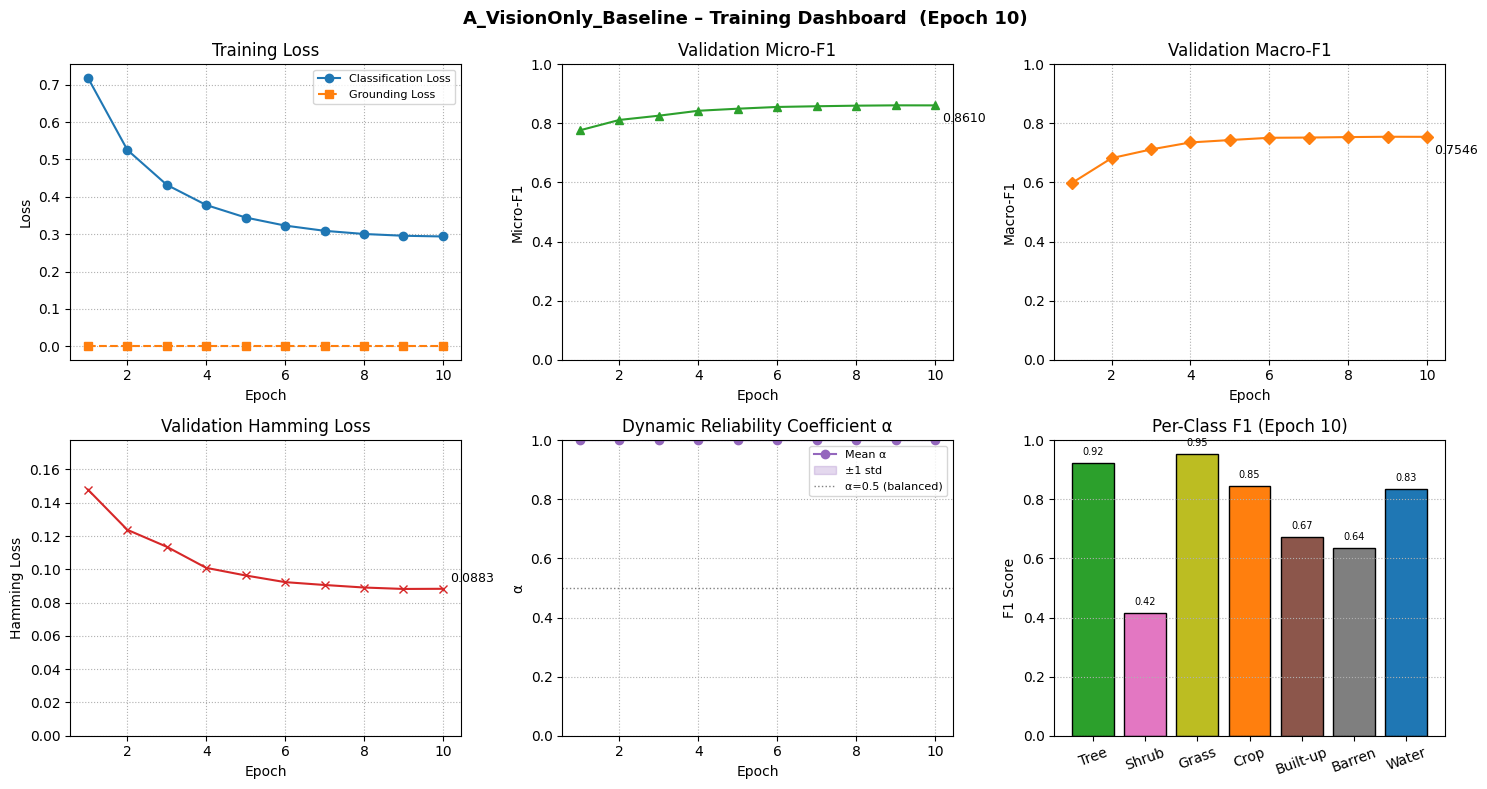


[A_VisionOnly_Baseline] Training complete. Best Val Micro-F1: 0.8612


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▁▁▁▁▁▁▁▁▁
train/alpha_std,▁▁▁▁▁▁▁▁▁▁
train/cls_loss,█▅▃▂▂▁▁▁▁▁
train/entropy_loss,▁▁▁▁▁▁▁▁▁▁
train/f1_Barren,▁▅▆▆▇▇████
train/f1_Built-up,▁▆▇▇▇█████
train/f1_Crop,▁▆▇▇██████
train/f1_Grass,▁▅▆▇▇█████
train/f1_Shrub,▁▅▆▇▇█████
+21,...


In [14]:
# Compute class-imbalance weights from the training split.
_labels_df_full = pd.read_csv(LABELS_CSV)
_train_val_df, _ = train_test_split(_labels_df_full, test_size=TEST_SPLIT, random_state=SEED)
_train_df, _     = train_test_split(_train_val_df, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED)

pos_weight = compute_pos_weights(_train_df, CLASSES, DEVICE)
bce_loss   = make_bce_loss(pos_weight)   # default classification loss

# Experiment A: Vision-Only Baseline
set_seed(SEED)
model_A = VisionOnlyBaseline(num_classes=NUM_CLASSES, attn_grid=ATTN_GRID)
history_A = train_model(
    model=model_A,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    loss_fn=bce_loss,
    gate_entropy_w=0.01,
    experiment_name='A_VisionOnly_Baseline',
)


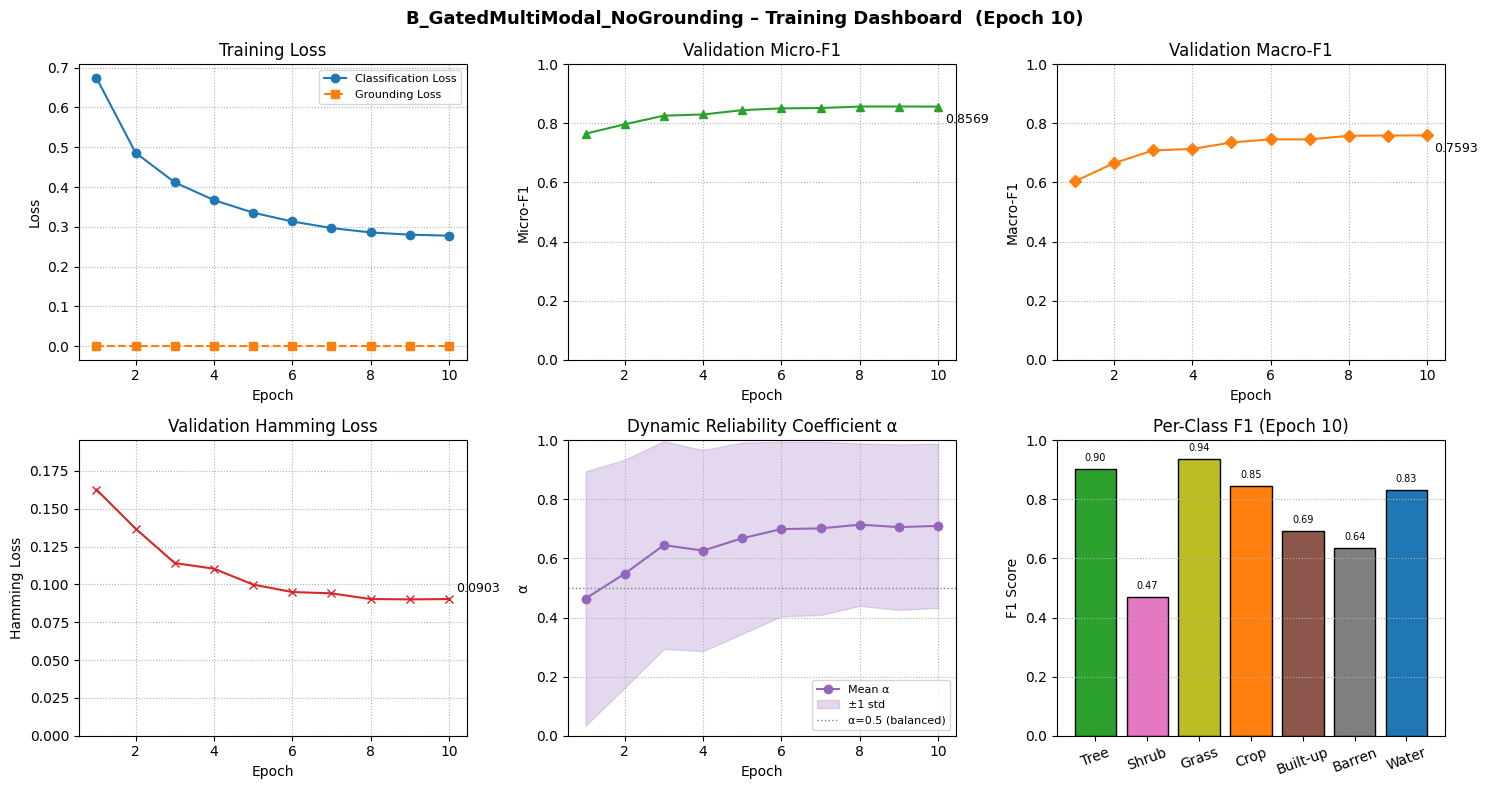


[B_GatedMultiModal_NoGrounding] Training complete. Best Val Micro-F1: 0.8572


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▄▅▆▇▇████
train/alpha_std,▆█▆▄▃▂▂▁▁▁
train/cls_loss,█▅▃▃▂▂▁▁▁▁
train/entropy_loss,▆▁▅▆▇▇████
train/f1_Barren,▁▄▅▆▇▇████
train/f1_Built-up,▁▄▅▆▆▇████
train/f1_Crop,▁▆▆▇▇█████
train/f1_Grass,▁▅▆▆▆▆▇▇██
train/f1_Shrub,▁▃▄▅▆▇▇███
+21,...


In [15]:
# Experiment B: Gated Multi-Modal (no grounding)
set_seed(SEED)
model_B = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_B = train_model(
    model=model_B,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    loss_fn=bce_loss,
    gate_entropy_w=0.01,
    experiment_name='B_GatedMultiModal_NoGrounding',
)


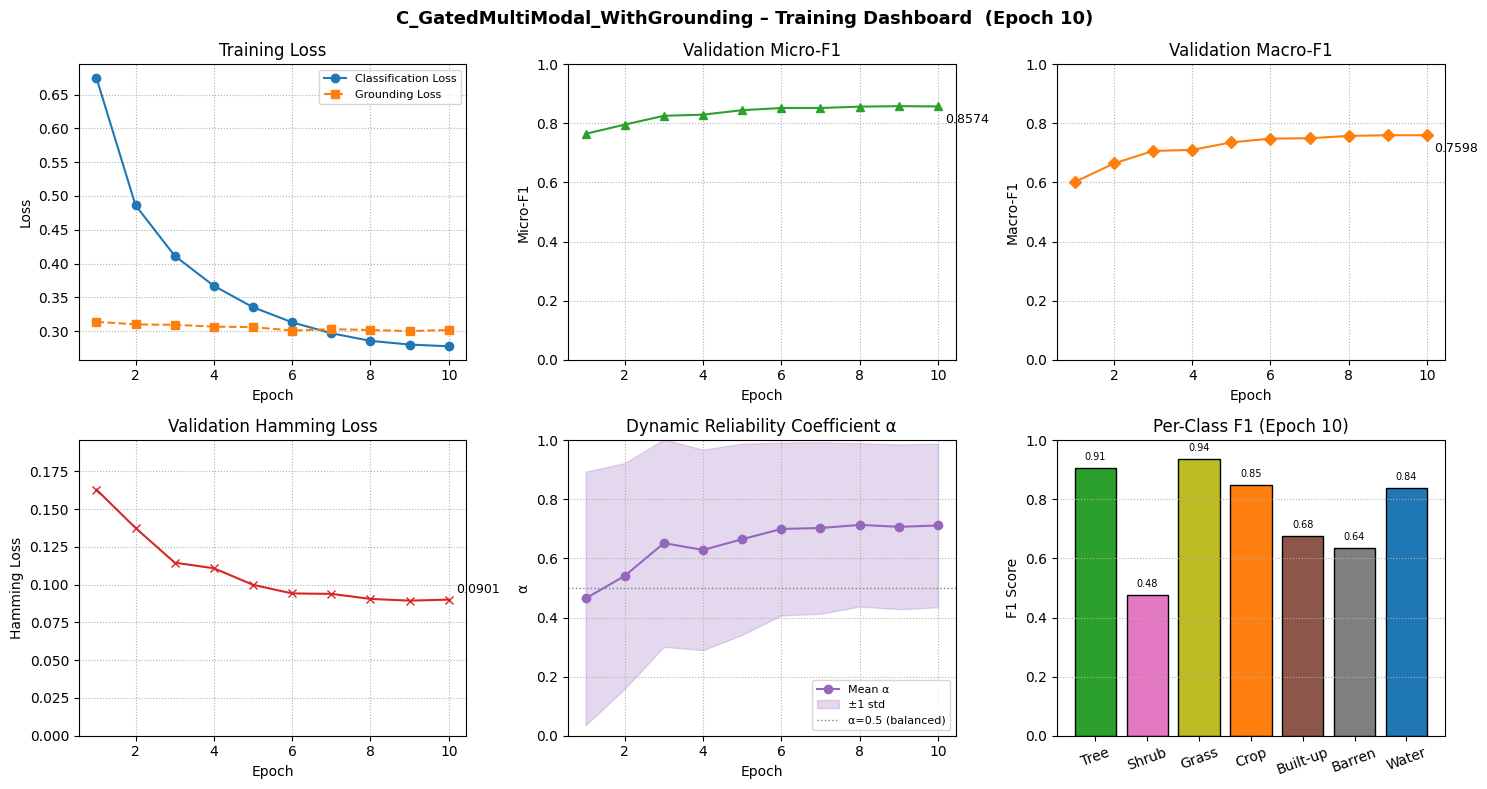


[C_GatedMultiModal_WithGrounding] Training complete. Best Val Micro-F1: 0.8584


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▄▅▆▇▇████
train/alpha_std,▆█▆▄▃▂▂▁▁▁
train/cls_loss,█▅▃▃▂▂▁▁▁▁
train/entropy_loss,▆▁▅▆▇▇████
train/f1_Barren,▁▄▅▆▇▇████
train/f1_Built-up,▁▄▅▆▆▇████
train/f1_Crop,▁▅▆▇▇█████
train/f1_Grass,▁▅▆▆▆▆▇▇██
train/f1_Shrub,▁▃▄▅▆▇▇███
+21,...


In [16]:
# Experiment C: Full Proposed Method (with per-class grounding)
set_seed(SEED)
model_C = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_C = train_model(
    model=model_C,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=True,
    loss_fn=bce_loss,
    gate_entropy_w=0.01,
    experiment_name='C_GatedMultiModal_WithGrounding',
)


## 8. Results

In [17]:
def eval_on_test(
    model: nn.Module,
    test_loader: DataLoader,
    device: torch.device,
    attn_loss_w: float,
    classes: list,
    use_attn_grounding: bool,
    model_name: str,
    loss_fn = None,
) -> dict:
    """Load best checkpoint and evaluate on the held-out test set."""
    ckpt_path = f'{model_name}_best.pt'
    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
        print(f"Loaded best checkpoint: {ckpt_path}")
    model.to(device)
    metrics = run_epoch(
        model, test_loader, None, device,
        attn_loss_w, classes, is_train=False,
        use_attn_grounding=use_attn_grounding,
        loss_fn=loss_fn,
        gate_entropy_w=0.0,
    )
    return metrics


# Phase 2 evaluation runs (outputs preserved)
results = {}
results['A_VisionOnly'] = eval_on_test(
    model_A, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='A_VisionOnly_Baseline',
    loss_fn=bce_loss,
)
results['B_GatedNoGround'] = eval_on_test(
    model_B, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='B_GatedMultiModal_NoGrounding',
    loss_fn=bce_loss,
)
results['C_GatedGrounded'] = eval_on_test(
    model_C, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=True, model_name='C_GatedMultiModal_WithGrounding',
    loss_fn=bce_loss,
)


Loaded best checkpoint: A_VisionOnly_Baseline_best.pt
Loaded best checkpoint: B_GatedMultiModal_NoGrounding_best.pt
Loaded best checkpoint: C_GatedMultiModal_WithGrounding_best.pt


In [18]:
# Summary table
rows = []
for exp_name, m in results.items():
    rows.append({
        'Experiment':   exp_name,
        'Micro-F1':     round(m['micro_f1'],   4),
        'Macro-F1':     round(m['macro_f1'],   4),
        'Hamming Loss': round(m['hamming'],     4),
        'α (mean)':     round(m['alpha_mean'],  3),
        'α (std)':      round(m['alpha_std'],   3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('phase2_results_summary.csv', index=False)

     Experiment  Micro-F1  Macro-F1  Hamming Loss  α (mean)  α (std)
   A_VisionOnly    0.8566    0.7529        0.0926     1.000    0.000
B_GatedNoGround    0.8646    0.7643        0.0869     0.714    0.279
C_GatedGrounded    0.8639    0.7633        0.0876     0.714    0.278


In [19]:
#  Per-class F1 comparison
per_class_rows = []
for exp_name, m in results.items():
    row = {'Experiment': exp_name}
    for cls in CLASSES:
        row[cls] = round(m[f'f1_{cls}'], 4)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))
per_class_df.to_csv('phase2_per_class_f1.csv', index=False)

     Experiment   Tree  Shrub  Grass   Crop  Built-up  Barren  Water
   A_VisionOnly 0.9164 0.4222 0.9493 0.8425    0.6222  0.6473 0.8704
B_GatedNoGround 0.9193 0.4744 0.9433 0.8522    0.7049  0.6600 0.7961
C_GatedGrounded 0.9204 0.4615 0.9427 0.8514    0.7097  0.6574 0.8000


## 9. Visualisations

All figures are exported at 300 DPI and saved as PNG files for inclusion in the report.

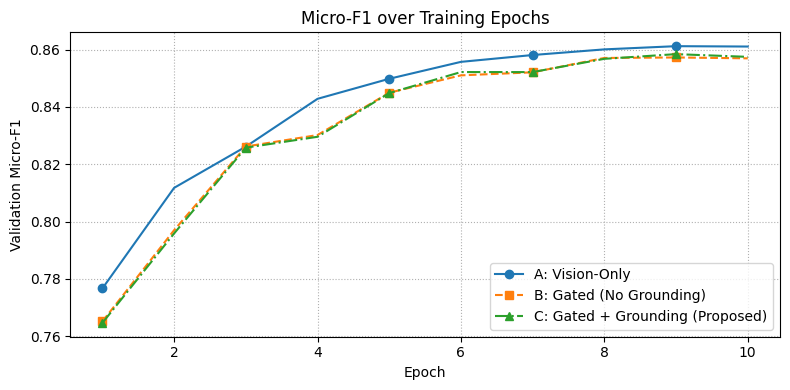

In [20]:
# Validation Micro-F1 over epochs
fig, ax = plt.subplots(figsize=(8, 4))

linestyles = ['-', '--', '-.']
markers    = ['o', 's', '^']
labels_plot = ['A: Vision-Only', 'B: Gated (No Grounding)', 'C: Gated + Grounding (Proposed)']

for hist, ls, mk, lbl in zip(
    [history_A, history_B, history_C], linestyles, markers, labels_plot
):
    epochs = [e['epoch'] for e in hist]
    f1s    = [e['micro_f1'] for e in hist]
    ax.plot(epochs, f1s, linestyle=ls, marker=mk, label=lbl, markevery=2)

ax.set_xlabel('Epoch')
ax.set_ylabel('Validation Micro-F1')
ax.set_title('Micro-F1 over Training Epochs')
ax.legend()
ax.grid(True, linestyle=':')
plt.tight_layout()
fig.savefig('fig1_micro_f1_epochs.png', dpi=300)
plt.show()

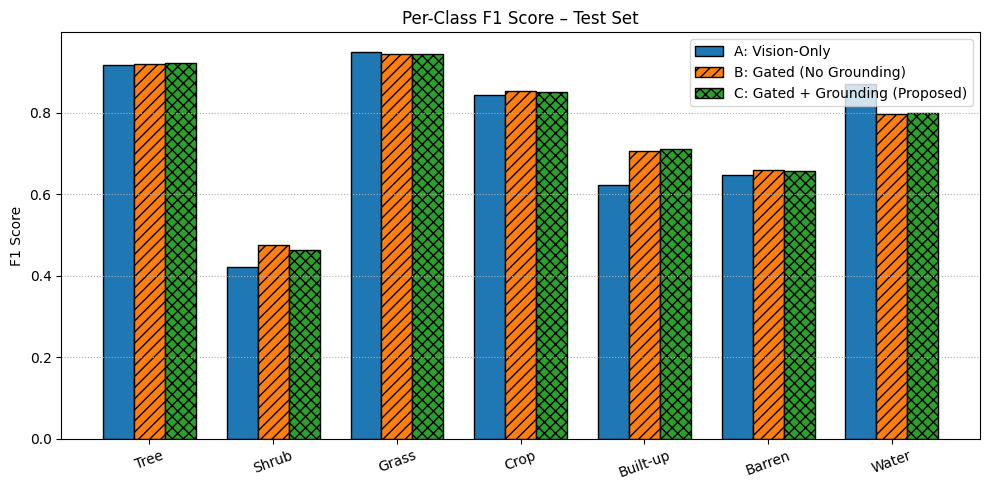

In [21]:
#  Per-class F1 bar chart
x     = np.arange(len(CLASSES))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
hatches = ['', '///', 'xxx']

for i, (exp_name, lbl, hatch) in enumerate(
    zip(results.keys(), labels_plot, hatches)
):
    vals = [results[exp_name][f'f1_{cls}'] for cls in CLASSES]
    ax.bar(x + i * width, vals, width, label=lbl, hatch=hatch, edgecolor='black')

ax.set_xticks(x + width)
ax.set_xticklabels(CLASSES, rotation=20)
ax.set_ylabel('F1 Score')
ax.set_title('Per-Class F1 Score – Test Set')
ax.legend()
ax.grid(axis='y', linestyle=':')
plt.tight_layout()
fig.savefig('fig2_per_class_f1.png', dpi=300)
plt.show()

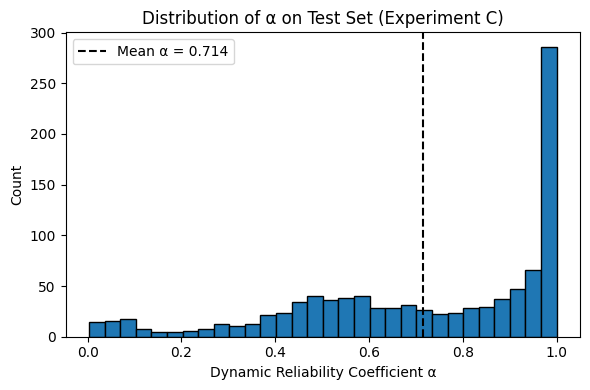

In [22]:
# Alpha distribution for Experiment C
                    # Collect α values on the test set for qualitative analysis
model_C.eval()
alpha_vals = []

with torch.no_grad():
    for batch in test_loader:
        imgs     = batch['image'].to(DEVICE)
        ids      = batch['input_ids'].to(DEVICE)
        attn_msk = batch['attn_mask'].to(DEVICE)
        _, alpha, _ = model_C(imgs, ids, attn_msk)
        alpha_vals.append(alpha.cpu().squeeze(1).numpy())

alpha_vals = np.concatenate(alpha_vals)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(alpha_vals, bins=30, edgecolor='black')
ax.set_xlabel('Dynamic Reliability Coefficient α')
ax.set_ylabel('Count')
ax.set_title('Distribution of α on Test Set (Experiment C)')
ax.axvline(alpha_vals.mean(), color='k', linestyle='--', label=f'Mean α = {alpha_vals.mean():.3f}')
ax.legend()
plt.tight_layout()
fig.savefig('fig3_alpha_distribution.png', dpi=300)
plt.show()

## 7. Asymmetric Focal Loss (for Experiment E)

**Asymmetric Focal Loss** of Ben-Baruch et al. (ICCV 2021), which is a
state-of-the-art multi-label loss that:

* Down-weights easy negatives with a higher focusing parameter
  `gamma_neg > gamma_pos` (typically 4 vs 0), so dominant negatives stop
  flooding the gradient.
* Optionally shifts negative logits by `clip` to ignore very-easy negatives
  entirely (`p_neg = max(p − clip, 0)`).
* Reduces to focal loss when `gamma_neg = gamma_pos` and to BCE when both
  gammas are 0.


In [23]:
class AsymmetricFocalLoss(nn.Module):
    """Asymmetric focal loss for multi-label classification.
    """
    def __init__(self, gamma_neg: float = 4.0, gamma_pos: float = 0.0,
                 clip: float = 0.05, eps: float = 1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip      = clip
        self.eps       = eps

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Probabilities for positive and negative classes
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos

        # Asymmetric probability shifting (only for negatives)
        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        # Basic cross-entropy with safety eps
        los_pos = targets       * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        # Asymmetric focusing (matched gradient implementation)
        if self.gamma_neg > 0 or self.gamma_pos > 0:
            pt0 = xs_pos * targets
            pt1 = xs_neg * (1 - targets)
            pt  = pt0 + pt1
            one_sided_gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
            one_sided_w = torch.pow(1 - pt, one_sided_gamma)
            loss = loss * one_sided_w

        return -loss.mean()


# Quick sanity check on a dummy tensor
_dummy_logits = torch.randn(4, NUM_CLASSES)
_dummy_labels = (torch.rand(4, NUM_CLASSES) > 0.7).float()
print("AsymmetricFocalLoss sanity check:",
      AsymmetricFocalLoss()(_dummy_logits, _dummy_labels).item())


AsymmetricFocalLoss sanity check: 0.24159982800483704


## 8. Experiment D — Gate-Entropy Ablation

**Research question for this experiment.** Is the dynamic, non-degenerate
fusion observed in Experiments B/C an emergent property of the architecture,
or does it depend on the binary-entropy regularizer applied to α?

**Hypothesis.** Without entropy regularization, the gate will collapse toward
α≈1 because the ViT features dominate early training and the gate
receives a much stronger gradient than the text branch, recovering
vision-only behavior despite the multi-modal architecture.

**Experimental setup.** Identical to Experiment B (gated multi-modal, no
grounding) except `gate_entropy_w = 0.0`. Same seed, same LR schedule, same
loss (BCE + pos_weight). This is the **principal ablation** of Phase 3 and
is designed to **severely affect the results** in line with the Phase 3
rubric.



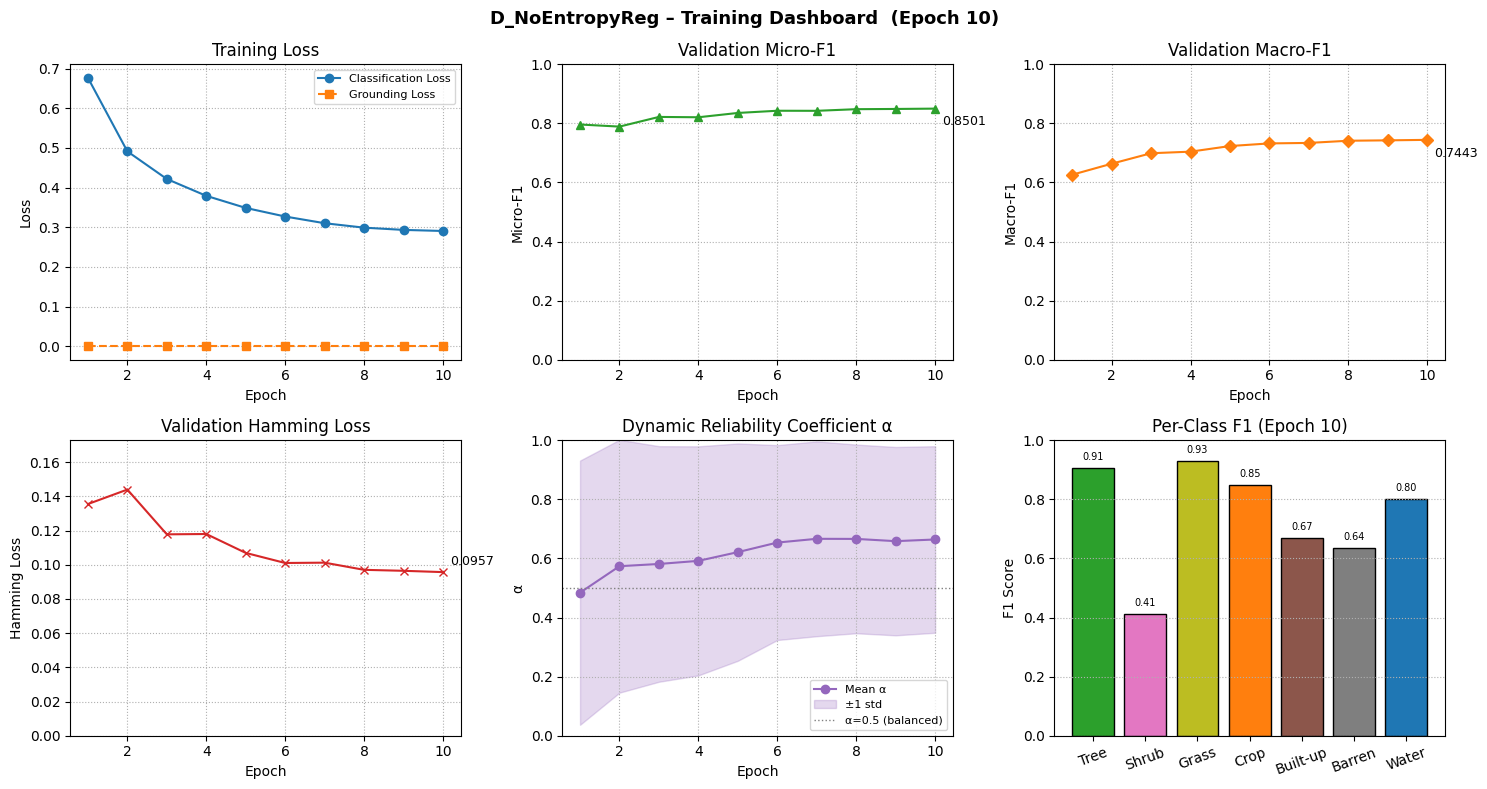


[D_NoEntropyReg] Training complete. Best Val Micro-F1: 0.8501


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▅▅▆▇▇████
train/alpha_std,▆█▆▅▃▃▂▁▁▁
train/cls_loss,█▅▃▃▂▂▁▁▁▁
train/entropy_loss,▁▁▁▁▁▁▁▁▁▁
train/f1_Barren,▁▄▅▆▇▇▇███
train/f1_Built-up,▁▄▅▆▆▇████
train/f1_Crop,▁▅▆▇▇▇████
train/f1_Grass,▁▆▇▇▇█████
train/f1_Shrub,▁▃▄▅▆▇▇███
+21,...


Loaded best checkpoint: D_NoEntropyReg_best.pt

Experiment D test results:
  micro_f1          : 0.8566
  macro_f1          : 0.7536
  hamming           : 0.0930
  f1_Tree           : 0.9121
  f1_Shrub          : 0.4353
  f1_Grass          : 0.9398
  f1_Crop           : 0.8485
  f1_Built-up       : 0.6984
  f1_Barren         : 0.6522
  f1_Water          : 0.7890
  cls_loss          : 0.3584
  grnd_loss         : 0.0000
  entropy_loss      : 0.0000
  alpha_mean        : 0.6742
  alpha_std         : 0.3129


In [24]:
# Experiment D: Gate-Entropy Ablation (lambda_entropy = 0)
# Architecture identical to B; only difference is gate_entropy_w = 0.
set_seed(SEED)
model_D = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_D = train_model(
    model=model_D,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=False,
    loss_fn=bce_loss,
    gate_entropy_w=0.0,
    experiment_name='D_NoEntropyReg',
)

# Evaluate Experiment D on the test set
results['D_NoEntropyReg'] = eval_on_test(
    model_D, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=False, model_name='D_NoEntropyReg',
    loss_fn=bce_loss,
)
print("\nExperiment D test results:")
for k, v in results['D_NoEntropyReg'].items():
    if isinstance(v, float):
        print(f"  {k:18s}: {v:.4f}")


## 9. Experiment E — Loss Function Ablation (Asymmetric Focal Loss)

**Research question for this experiment.** Does replacing BCE+pos_weight with
a multi-label loss that is more closely matched to the F1/overlap objective
(Asymmetric Focal Loss) recover the small per-class regressions observed in
Experiment C, particularly on Water and Grass?


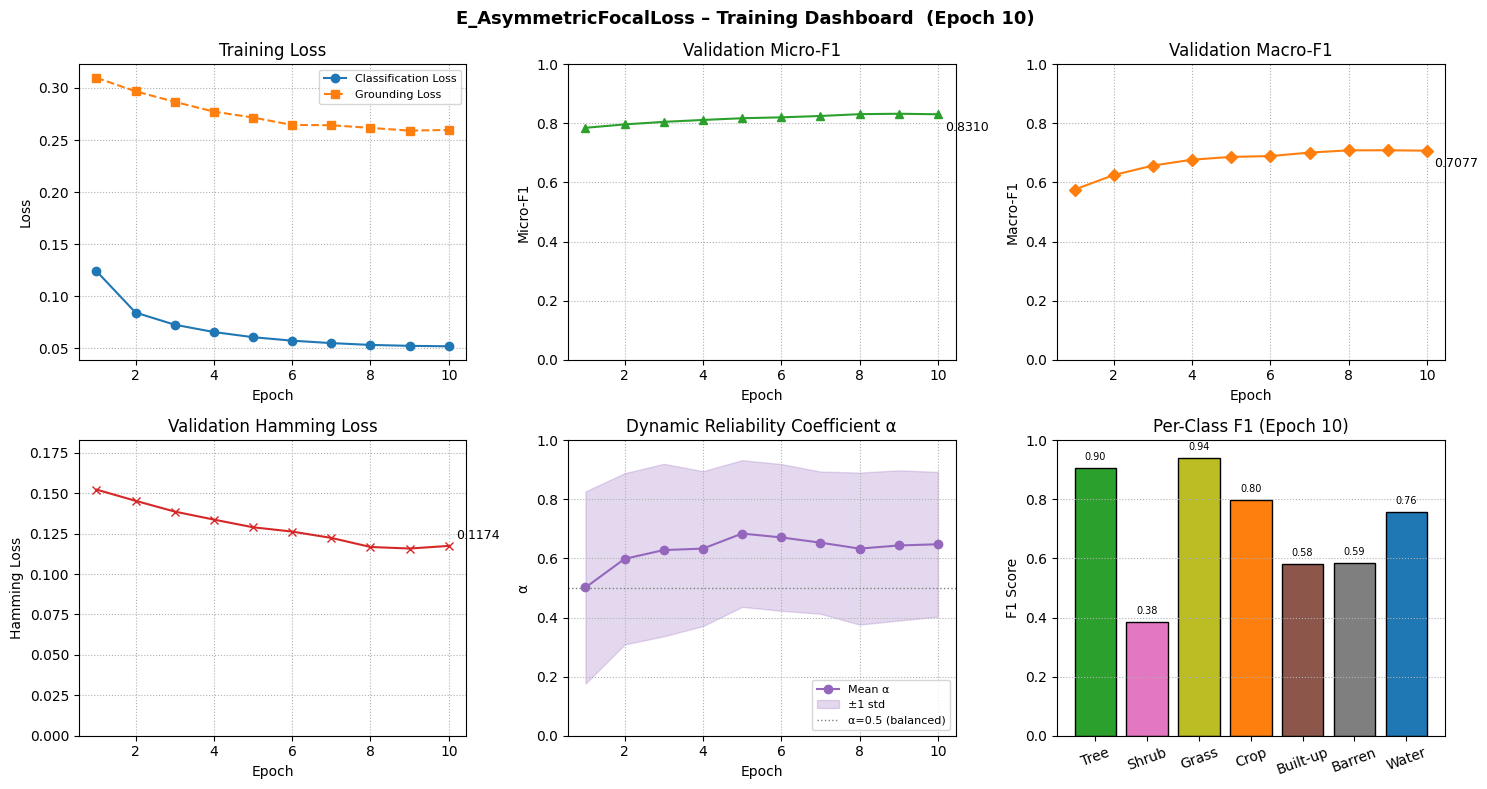


[E_AsymmetricFocalLoss] Training complete. Best Val Micro-F1: 0.8327


epoch,▁▂▃▃▄▅▆▆▇█
train/alpha_mean,▁▅▆▇██████
train/alpha_std,▆█▅▄▂▂▂▁▁▁
train/cls_loss,█▄▃▂▂▂▁▁▁▁
train/entropy_loss,▃▁▅▆▇▇▇███
train/f1_Barren,▁▅▆▆▇▇████
train/f1_Built-up,▁▆▆▇▇█████
train/f1_Crop,▁▆▆▇▇█████
train/f1_Grass,▁▂▃▄▅▆▇███
train/f1_Shrub,▁▃▆▇▇█████
+21,...


Loaded best checkpoint: E_AsymmetricFocalLoss_best.pt

Experiment E test results:
  micro_f1          : 0.8329
  macro_f1          : 0.7125
  hamming           : 0.1174
  f1_Tree           : 0.9141
  f1_Shrub          : 0.3750
  f1_Grass          : 0.9438
  f1_Crop           : 0.7867
  f1_Built-up       : 0.5921
  f1_Barren         : 0.6068
  f1_Water          : 0.7692
  cls_loss          : 0.0595
  grnd_loss         : 0.2646
  entropy_loss      : 0.0000
  alpha_mean        : 0.6518
  alpha_std         : 0.2501


In [25]:
# Experiment E: Loss Function Ablation (Asymmetric Focal Loss)
asl_loss = AsymmetricFocalLoss(gamma_neg=4.0, gamma_pos=0.0, clip=0.05)

set_seed(SEED)
model_E = GatedMultiModalModel(
    num_classes=NUM_CLASSES, attn_grid=ATTN_GRID,
    text_model_id=TEXT_MODEL_ID,
)
history_E = train_model(
    model=model_E,
    train_loader=train_loader, val_loader=val_loader,
    num_epochs=NUM_EPOCHS, lr=LEARNING_RATE,
    attn_loss_w=ATTN_LOSS_W, device=DEVICE,
    classes=CLASSES,
    use_attn_grounding=True,
    loss_fn=asl_loss,                      # <-- the ablation
    gate_entropy_w=0.01,
    experiment_name='E_AsymmetricFocalLoss',
)

# Evaluate Experiment E on the test set
results['E_AsymmetricFocal'] = eval_on_test(
    model_E, test_loader, DEVICE, ATTN_LOSS_W, CLASSES,
    use_attn_grounding=True, model_name='E_AsymmetricFocalLoss',
    loss_fn=asl_loss,
)
print("\nExperiment E test results:")
for k, v in results['E_AsymmetricFocal'].items():
    if isinstance(v, float):
        print(f"  {k:18s}: {v:.4f}")


## 10. Updated Summary (Experiments A–E)


In [26]:
# Full A-E summary table
exp_label = {
    'A_VisionOnly':       'A: Vision-Only (baseline)',
    'B_GatedNoGround':    'B: Gated, no grounding',
    'C_GatedGrounded':    'C: Gated + grounding (proposed)',
    'D_NoEntropyReg':     'D: Ablation - no entropy reg.',
    'E_AsymmetricFocal':  'E: Ablation - asymmetric focal loss',
}

rows = []
for exp_key, m in results.items():
    rows.append({
        'Experiment':   exp_label.get(exp_key, exp_key),
        'Micro-F1':     round(m['micro_f1'],   4),
        'Macro-F1':     round(m['macro_f1'],   4),
        'Hamming Loss': round(m['hamming'],    4),
        'alpha (mean)': round(m['alpha_mean'], 3),
        'alpha (std)':  round(m['alpha_std'],  3),
    })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('phase3_results_summary.csv', index=False)


                         Experiment  Micro-F1  Macro-F1  Hamming Loss  alpha (mean)  alpha (std)
          A: Vision-Only (baseline)    0.8566    0.7529        0.0926         1.000        0.000
             B: Gated, no grounding    0.8646    0.7643        0.0869         0.714        0.279
    C: Gated + grounding (proposed)    0.8639    0.7633        0.0876         0.714        0.278
      D: Ablation - no entropy reg.    0.8566    0.7536        0.0930         0.674        0.313
E: Ablation - asymmetric focal loss    0.8329    0.7125        0.1174         0.652        0.250


In [27]:
# Full A-E per-class F1 table

per_class_rows = []
for exp_key, m in results.items():
    row = {'Experiment': exp_label.get(exp_key, exp_key)}
    for cls in CLASSES:
        row[cls] = round(m[f'f1_{cls}'], 4)
    per_class_rows.append(row)

per_class_df = pd.DataFrame(per_class_rows)
print(per_class_df.to_string(index=False))
per_class_df.to_csv('phase3_per_class_f1.csv', index=False)


                         Experiment   Tree  Shrub  Grass   Crop  Built-up  Barren  Water
          A: Vision-Only (baseline) 0.9164 0.4222 0.9493 0.8425    0.6222  0.6473 0.8704
             B: Gated, no grounding 0.9193 0.4744 0.9433 0.8522    0.7049  0.6600 0.7961
    C: Gated + grounding (proposed) 0.9204 0.4615 0.9427 0.8514    0.7097  0.6574 0.8000
      D: Ablation - no entropy reg. 0.9121 0.4353 0.9398 0.8485    0.6984  0.6522 0.7890
E: Ablation - asymmetric focal loss 0.9141 0.3750 0.9438 0.7867    0.5921  0.6068 0.7692


## 11. Qualitative Analysis — Sample Input/Output Panels


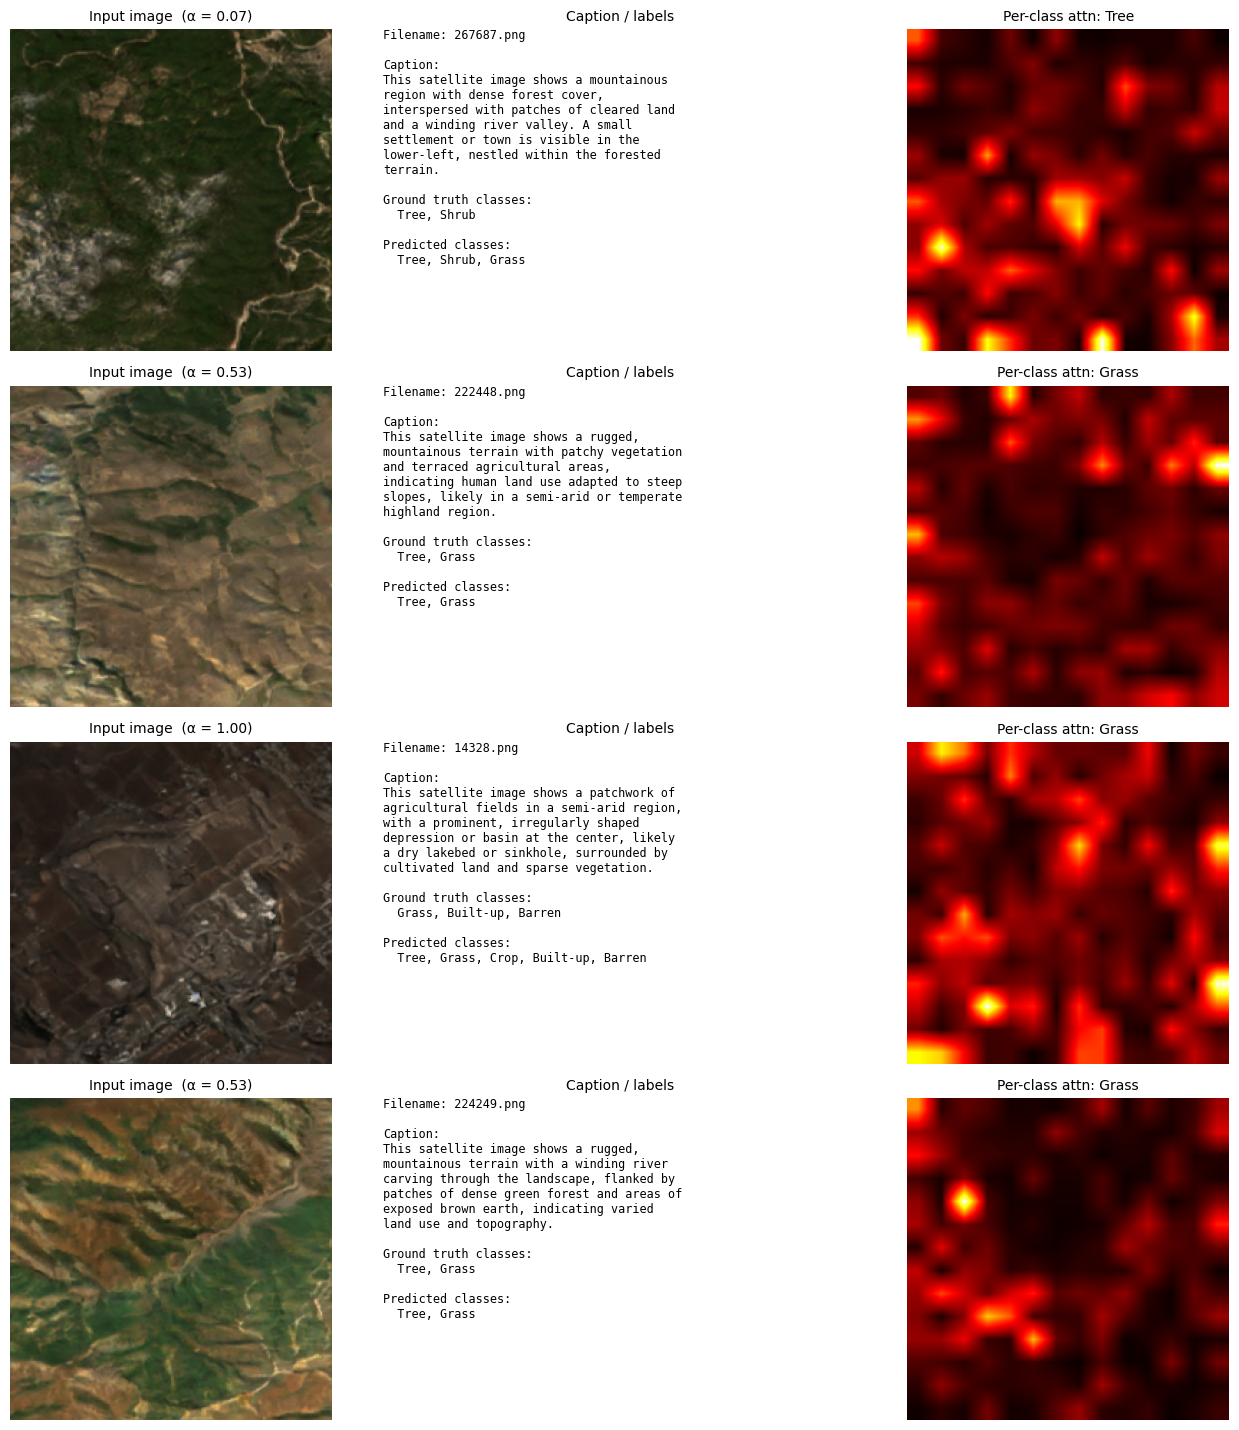

In [28]:
# Sample N test images and visualize input/output panels
import textwrap

NUM_SAMPLES = 4
model_C.eval()

# Pull a small batch of diverse samples
sample_batch = next(iter(test_loader))
n = min(NUM_SAMPLES, sample_batch['image'].shape[0])

with torch.no_grad():
    logits, alphas, attn_maps = model_C(
        sample_batch['image'][:n].to(DEVICE),
        sample_batch['input_ids'][:n].to(DEVICE),
        sample_batch['attn_mask'][:n].to(DEVICE),
    )
    probs = torch.sigmoid(logits).cpu().numpy()
    preds = (probs > 0.5).astype(int)
    alphas = alphas.cpu().numpy().squeeze(1)
    attn_maps = attn_maps.cpu().numpy()
    gt_labels = sample_batch['labels'][:n].numpy().astype(int)

# Load captions for these samples
_captions_df = pd.read_csv(CAPTIONS_CSV).set_index('filename')

# De-normalize images for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(n, 3, figsize=(14, 3.6 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for i in range(n):
    fname = sample_batch['filename'][i]
    caption = str(_captions_df.loc[fname, CAPTION_COL]) if fname in _captions_df.index else '(missing caption)'

    # --- column 1: input image ---
    img = sample_batch['image'][i].permute(1, 2, 0).numpy()
    img = (img * std + mean).clip(0, 1)
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f'Input image  (α = {alphas[i]:.2f})', fontsize=10)
    axes[i, 0].axis('off')

    # --- column 2: GT vs predicted labels ---
    axes[i, 1].axis('off')
    gt_classes   = [c for c, v in zip(CLASSES, gt_labels[i]) if v]
    pred_classes = [c for c, v in zip(CLASSES, preds[i])     if v]
    text = (
        f'Filename: {fname}\n\n'
        f'Caption:\n{textwrap.fill(caption, width=42)}\n\n'
        f'Ground truth classes:\n  {", ".join(gt_classes) if gt_classes else "(none)"}\n\n'
        f'Predicted classes:\n  {", ".join(pred_classes) if pred_classes else "(none)"}'
    )
    axes[i, 1].text(0, 1, text, ha='left', va='top', fontsize=8.5,
                    family='monospace', transform=axes[i, 1].transAxes)
    axes[i, 1].set_title('Caption / labels', fontsize=10)

    # --- column 3: per-class attention for dominant GT class ---
    if gt_classes:
        # Pick the most-attended GT class
        dominant_idx = max(
            [k for k, v in enumerate(gt_labels[i]) if v],
            key=lambda k: attn_maps[i, k].mean()
        )
        dominant_cls = CLASSES[dominant_idx]
        axes[i, 2].imshow(attn_maps[i, dominant_idx], cmap='hot', interpolation='bilinear')
        axes[i, 2].set_title(f'Per-class attn: {dominant_cls}', fontsize=10)
    else:
        axes[i, 2].text(0.5, 0.5, '(no positive classes)', ha='center', va='center')
        axes[i, 2].set_title('Per-class attention', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()
fig.savefig('fig4_qualitative_samples.png', dpi=300, bbox_inches='tight')
plt.show()


## 12. Per-Class α Analysis — Why Do Water and Grass Drop?

Class         mean alpha (present)    count
  Tree                         0.552      552
  Shrub                        0.279       52
  Grass                        0.709      858
  Crop                         0.933      350
  Built-up                     0.873       49
  Barren                       0.920      197
  Water                        0.257       50


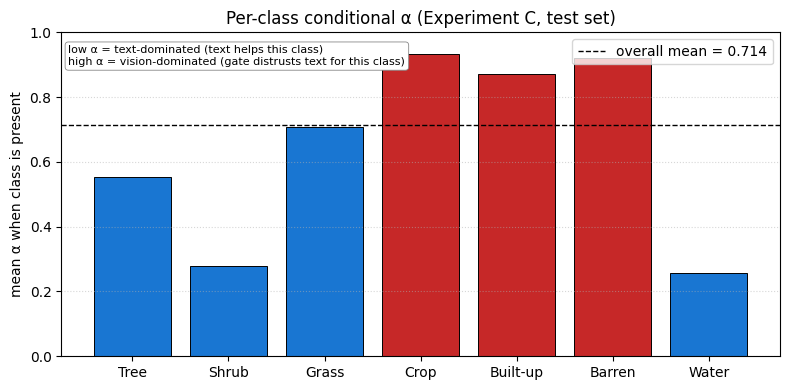

In [29]:
# Per-class conditional alpha analysis on the test set, using Experiment C.
model_C.eval()

all_alphas = []
all_labels = []
with torch.no_grad():
    for batch in test_loader:
        imgs     = batch['image'].to(DEVICE)
        ids      = batch['input_ids'].to(DEVICE)
        attn_msk = batch['attn_mask'].to(DEVICE)
        _, alpha, _ = model_C(imgs, ids, attn_msk)
        all_alphas.append(alpha.cpu().numpy().squeeze(1))
        all_labels.append(batch['labels'].numpy())

all_alphas = np.concatenate(all_alphas)
all_labels = np.concatenate(all_labels, axis=0)

# Mean alpha conditional on each class being present
print(f"{'Class':10s}  {'mean alpha (present)':>22s}  {'count':>7s}")
rows = []
for c, cls in enumerate(CLASSES):
    mask = all_labels[:, c].astype(bool)
    if mask.sum() == 0:
        continue
    mean_a = all_alphas[mask].mean()
    count  = int(mask.sum())
    rows.append((cls, mean_a, count))
    print(f"  {cls:10s}  {mean_a:>22.3f}  {count:>7d}")

# Plot it
fig, ax = plt.subplots(figsize=(8, 4))
labels_  = [r[0] for r in rows]
means    = [r[1] for r in rows]
colors   = ['#1976d2' if m < all_alphas.mean() else '#c62828' for m in means]
bars = ax.bar(labels_, means, color=colors, edgecolor='black', linewidth=0.7)
ax.axhline(all_alphas.mean(), linestyle='--', color='black', linewidth=1,
           label=f'overall mean = {all_alphas.mean():.3f}')
ax.set_ylabel('mean α when class is present')
ax.set_ylim(0, 1)
ax.set_title('Per-class conditional α (Experiment C, test set)')
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)

# Annotation: interpret per-class result
ax.text(0.01, 0.96,
        'low α = text-dominated (text helps this class)\n'
        'high α = vision-dominated (gate distrusts text for this class)',
        transform=ax.transAxes, fontsize=8, va='top',
        bbox=dict(boxstyle='round,pad=0.3', fc='#fff', ec='#888', lw=0.6))

plt.tight_layout()
fig.savefig('fig5_per_class_alpha.png', dpi=300, bbox_inches='tight')
plt.show()
